In [1]:
import os
import shutil
import subprocess
import sys

import pandas as pd

print(f"Using kernel: {sys.executable}")

# Keep the notebook on the active kernel instead of mixing in processing_venv.
sys.path = [p for p in sys.path if "processing_venv" not in p.replace('\\', '/')]
os.environ.pop("VIRTUAL_ENV", None)

required_packages = [
    "yt-dlp",
    "faster-whisper",
    "google-cloud-storage",
    "ffmpeg-python",
    "python-dotenv",
]

print("Ensuring notebook dependencies are installed in the active kernel...")
for package in required_packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=False)

print("Dependency check complete.")

if shutil.which("ffmpeg"):
    print("FFmpeg is available on PATH.")
else:
    print("FFmpeg is not available on PATH. Install it separately and restart the kernel.")

print("\n" + "=" * 60)
print("Setup complete. The notebook now uses the active kernel environment.")
print("=" * 60)

Using kernel: d:\conda_envs\ma_env\python.exe
Ensuring notebook dependencies are installed in the active kernel...
Dependency check complete.
FFmpeg is available on PATH.

Setup complete. The notebook now uses the active kernel environment.


In [6]:
# Load only Instagram data (Camihawke Cleaned)
data_folder = os.getcwd()
camihawke_folder = os.path.join(data_folder,"Data", "Camihawke", "Cleaned")
if os.path.exists(camihawke_folder):
    print("Loading Instagram data...")
    ig_posts = pd.read_parquet(os.path.join(camihawke_folder, "ig_posts_cleaned.parquet"))
    ig_comments = pd.read_parquet(os.path.join(camihawke_folder, "ig_comments_cleaned.parquet"))
    print(f"  ✓ Instagram posts: {len(ig_posts)} records")
    print(f"  ✓ Instagram comments: {len(ig_comments)} records")


Loading Instagram data...
  ✓ Instagram posts: 1540 records
  ✓ Instagram comments: 499752 records


In [7]:
ig_posts.head()

,media_id,caption,comments_count,like_count,media_product_type,media_type,permalink,timestamp,reach,saved,views,total_interactions,comments_downloaded,year,Not_reel,month,dayofweek,hour
0,17941939319341563,Pronta a fissarmi goal irraggiungibili anche q...,125,43223,REELS,VIDEO,https://www.instagram.com/reel/Cm6WPZRhfBB/,2023-01-02 11:53:19,906443.0,1212.0,1138605.0,44602.0,1,2023,False,1,Monday,11
1,17992425124653410,2023: ritagliarsi ancora piu tempo (prezioso) ...,34,43776,FEED,CAROUSEL_ALBUM,https://www.instagram.com/p/Cm9ZVRxj1jO/,2023-01-03 00:00:00,373101.0,160.0,0.0,43970.0,-1,2023,True,1,Tuesday,0
2,18018137773483891,Secondo voi chi è che per la seconda volta con...,102,74641,FEED,CAROUSEL_ALBUM,https://www.instagram.com/p/Cm_dQosr6Ng/,2023-01-04 11:26:30,522935.0,259.0,0.0,75003.0,1,2023,True,1,Wednesday,11
3,17949420668402803,Spero di essere stata chiara.,469,80664,REELS,VIDEO,https://www.instagram.com/reel/CnCVAF6hurE/,2023-01-05 14:11:43,1356965.0,1987.0,1692538.0,83205.0,1,2023,False,1,Thursday,14
4,17951287544459659,Oggi è il nostro anniversario. Cominciano a e...,529,86374,REELS,VIDEO,https://www.instagram.com/reel/CnHM081hyz9/,2023-01-07 00:00:00,1035853.0,1636.0,1280011.0,88625.0,-1,2023,False,1,Saturday,0


In [8]:
ig_posts.media_type.value_counts()

media_type
IMAGE             641
CAROUSEL_ALBUM    501
VIDEO             398
Name: count, dtype: int64

In [9]:
ig_posts.permalink

0       https://www.instagram.com/reel/Cm6WPZRhfBB/
1          https://www.instagram.com/p/Cm9ZVRxj1jO/
2          https://www.instagram.com/p/Cm_dQosr6Ng/
3       https://www.instagram.com/reel/CnCVAF6hurE/
4       https://www.instagram.com/reel/CnHM081hyz9/
                           ...                     
1584       https://www.instagram.com/p/BKQOxe7DsSn/
1585       https://www.instagram.com/p/BKIl7V4jaRX/
1586       https://www.instagram.com/p/BJuqgvVjHc6/
1587       https://www.instagram.com/p/BJVAYoTD9va/
1588       https://www.instagram.com/p/BJP4cIdjtaj/
Name: permalink, Length: 1540, dtype: object

In [10]:
# Separate links by media type
media_type_groups = ig_posts.groupby('media_type')

# Create dictionaries to store links for each media type
links_by_type = {}

for media_type, group in media_type_groups:
    links_by_type[media_type] = group['permalink'].tolist()

# Display the results
for media_type, links in links_by_type.items():
    print(f"\n{media_type}: {len(links)} posts")
    for link in links[:5]:  # Show first 5 links
        print(f"  {link}")
    if len(links) > 5:
        print(f"  ... and {len(links) - 5} more")

# Separate links by media type into different variables
video_links = links_by_type.get('VIDEO', [])
carousel_links = links_by_type.get('CAROUSEL_ALBUM', [])
image_links = links_by_type.get('IMAGE', [])

print(f"\nVIDEO: {len(video_links)} posts")
print(f"CAROUSEL_ALBUM: {len(carousel_links)} posts")
print(f"IMAGE: {len(image_links)} posts")

# Additionally, for VIDEO posts, separate by media_product_type (if available)
if 'media_product_type' in ig_posts.columns:
    ig_posts_video = ig_posts[ig_posts['media_type'] == 'VIDEO']
    product_groups = ig_posts_video.groupby('media_product_type')
    video_links_by_product = {ptype: grp['permalink'].tolist() for ptype, grp in product_groups}

    print("\nVIDEO posts by media_product_type:")
    for ptype, links in video_links_by_product.items():
        print(f"  {ptype}: {len(links)} posts")
        for link in links[:5]:
            print(f"    {link}")
        if len(links) > 5:
            print(f"    ... and {len(links) - 5} more")
else:
    print("\nColumn 'media_product_type' not found in ig_posts; cannot split VIDEO by product type.")


CAROUSEL_ALBUM: 501 posts
  https://www.instagram.com/p/Cm9ZVRxj1jO/
  https://www.instagram.com/p/Cm_dQosr6Ng/
  https://www.instagram.com/p/CnW4U_eD67J/
  https://www.instagram.com/p/CnhzXtUPJbk/
  https://www.instagram.com/p/CnkQmCbvW_6/
  ... and 496 more

IMAGE: 641 posts
  https://www.instagram.com/p/CoPWpOqLv-M/
  https://www.instagram.com/p/CoR9wsfrTPG/
  https://www.instagram.com/p/CopXu2Ij59h/
  https://www.instagram.com/p/CpSQ99wDsuF/
  https://www.instagram.com/p/CpaJeUCDGDS/
  ... and 636 more

VIDEO: 398 posts
  https://www.instagram.com/reel/Cm6WPZRhfBB/
  https://www.instagram.com/reel/CnCVAF6hurE/
  https://www.instagram.com/reel/CnHM081hyz9/
  https://www.instagram.com/reel/CnMWOAShvnT/
  https://www.instagram.com/reel/CnR28O2h0VM/
  ... and 393 more

VIDEO: 398 posts
CAROUSEL_ALBUM: 501 posts
IMAGE: 641 posts

VIDEO posts by media_product_type:
  FEED: 85 posts
    https://www.instagram.com/p/CU5FviYIUsz/
    https://www.instagram.com/p/CUj_2xhjw2v/
    https://www.

In [11]:
# Dictionary of video dataframes: one for FEED and one for REELS
ig_posts_video_sets = {}
if "media_product_type" in ig_posts.columns:
    ig_posts_video = ig_posts[ig_posts["media_type"] == "VIDEO"].copy()
    ig_posts_video_sets["FEED"] = ig_posts_video[ig_posts_video["media_product_type"] == "FEED"].copy()
    ig_posts_video_sets["REELS"] = ig_posts_video[ig_posts_video["media_product_type"] == "REELS"].copy()

    print(f"FEED videos: {len(ig_posts_video_sets['FEED'])}")
    print(f"REELS videos: {len(ig_posts_video_sets['REELS'])}")
else:
    print("Column 'media_product_type' not found in ig_posts.")

# Save FEED and REELS links separately
feed_links = ig_posts_video_sets.get("FEED", pd.DataFrame()).permalink.tolist()
reels_links = ig_posts_video_sets.get("REELS", pd.DataFrame()).permalink.tolist()

# Fallback if not present but video_links_by_product exists
if not feed_links and "video_links_by_product" in globals():
    feed_links = video_links_by_product.get("FEED", [])
if not reels_links and "video_links_by_product" in globals():
    reels_links = video_links_by_product.get("REELS", [])

# Persist to disk
with open("feed_links.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(feed_links))

with open("reels_links.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(reels_links))

print(f"Saved {len(feed_links)} FEED links to feed_links.txt")
print(f"Saved {len(reels_links)} REELS links to reels_links.txt")


FEED videos: 85
REELS videos: 313
Saved 85 FEED links to feed_links.txt
Saved 313 REELS links to reels_links.txt


In [2]:
import os

try:
    from faster_whisper import WhisperModel
except Exception as exc:
    raise RuntimeError("faster-whisper is not available in the active kernel. Run the setup cell first and restart the kernel if needed.") from exc

# Initialize the model once and reuse it for every video.
print("Loading Whisper large-v3-turbo on CPU...")
model = WhisperModel("large-v3-turbo", device="cpu", compute_type="float32")

def transcribe_audio(video_path, output_folder):
    """Transcribes video audio and saves timestamped text to a file."""
    print(f"Transcribing audio for {os.path.basename(video_path)}...")

    segments, info = model.transcribe(video_path, beam_size=5)

    print(f"Detected primary language: '{info.language}' with {info.language_probability * 100:.1f}% confidence")

    transcript_path = os.path.join(output_folder, "transcription.txt")

    with open(transcript_path, "w", encoding="utf-8") as f:
        for segment in segments:
            line = f"[{segment.start:.2f}s -> {segment.end:.2f}s] {segment.text}\n"
            f.write(line)
            print(line.strip())

    print(f"Successfully saved transcription to {transcript_path}")

d:\conda_envs\ma_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Whisper large-v3-turbo on CPU...


In [ ]:
import os
import subprocess
import shutil
import json
from pathlib import Path
from datetime import datetime
try:
    import yt_dlp
except ImportError:
    %pip install yt-dlp
    import yt_dlp

try:
    from tqdm import tqdm
except ImportError:
    %pip install tqdm
    from tqdm import tqdm

import glob
import pandas as pd

# Configuration
DATASET_DIR = "multimodal_dataset"
SCENE_THRESHOLD = 0.4
PROCESSED_URLS_FILE = "processed_urls.txt"
FAILED_DOWNLOADS_FILE = "failed_downloads.csv"

def folder_matches_url(folder: Path, url: str) -> bool:
    """Check if a folder corresponds to a given URL by checking folder name or info.json."""
    # Fast check: folder name in url (common for yt-dlp ids)
    if folder.name in url:
        return True
    # Check .info.json files for matching webpage/original url
    for info_file in folder.glob("*.info.json"):
        try:
            data = json.loads(info_file.read_text(encoding="utf-8"))
            for key in ("webpage_url", "original_url", "url"):
                val = data.get(key)
                if isinstance(val, str) and val == url:
                    return True
        except Exception:
            continue
    return False

def check_download_status(dataset_dir, urls):
    """Check which URLs have been downloaded and return status report."""
    dataset_path = Path(dataset_dir)
    subdirs = [p for p in dataset_path.iterdir() if p.is_dir()] if dataset_path.exists() else []
    
    downloaded = []
    not_downloaded = []
    
    for url in urls:
        match = None
        for folder in subdirs:
            if folder_matches_url(folder, url):
                match = folder
                break
        
        if match is None:
            not_downloaded.append(url)
        else:
            downloaded.append((url, str(match)))
    
    return downloaded, not_downloaded

def extract_frames(video_path, output_folder):
    """Uses FFmpeg to extract first frame, 1-second frame, and scene changes."""
    os.makedirs(output_folder, exist_ok=True)

    print(f"  Extracting frames for {os.path.basename(video_path)}...")

    # 1. Extract the very first frame (0 seconds)
    first_frame_path = os.path.join(output_folder, "frame_00_first.jpg")
    subprocess.run(
        ["ffmpeg", "-y", "-i", video_path, "-ss", "00:00:00", "-vframes", "1", "-q:v", "2", first_frame_path],
        check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

    # 2. Extract the frame at exactly 1 second
    second_frame_path = os.path.join(output_folder, "frame_01_second.jpg")
    subprocess.run(
        ["ffmpeg", "-y", "-i", video_path, "-ss", "00:00:01", "-vframes", "1", "-q:v", "2", second_frame_path],
        check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

    # 3. Extract remaining frames based on scene changes
    output_pattern = os.path.join(output_folder, "frame_%04d_scene.jpg")
    command = [
        "ffmpeg", "-y", "-i", video_path, "-vf", f"select='gt(scene,{SCENE_THRESHOLD})'",
        "-vsync", "vfr", "-q:v", "2", output_pattern
    ]
    try:
        subprocess.run(command, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        print(f"  ✓ Successfully extracted frames")
    except subprocess.CalledProcessError as e:
        print(f"  ✗ Error extracting scene frames: {e}")

def process_instagram_url(url):
    """Downloads an Instagram video and extracts its data. Returns (success, result_or_error)."""
    print(f"\n▶ Processing: {url}")
    ydl_opts = {
        'outtmpl': f'{DATASET_DIR}/%(id)s/%(id)s.%(ext)s',
        'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]/best',
        'writeinfojson': True,
        'sleep_interval_requests': 15,
        'sleep_interval': 10,
        'max_sleep_interval': 50,
    }

    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            info_dict = ydl.extract_info(url, download=True)
            video_id = info_dict.get('id', 'unknown_id')

        video_folder = os.path.join(DATASET_DIR, video_id)

        # Check if metadata file exists (indicates successful download)
        info_json_path = os.path.join(video_folder, f"{video_id}.info.json")
        if not os.path.exists(info_json_path):
            error_msg = f"Metadata file not found for {video_id}"
            print(f"  ✗ {error_msg}")
            return False, error_msg

        # Look for the video file
        video_files = glob.glob(os.path.join(video_folder, "*.mp4"))
        if not video_files:
            error_msg = f"No video file found in {video_id}/ (but metadata exists)"
            print(f"  ⚠ {error_msg}")
            return False, error_msg

        video_path = video_files[0]
        frames_folder = os.path.join(video_folder, "frames")

        print(f"  ✓ Downloaded video to {video_id}/")
        extract_frames(video_path, frames_folder)
        transcribe_audio(video_path, video_folder)

        has_music = False
        if info_dict.get('acodec') and info_dict['acodec'] != 'none':
            has_music = True
        else:
            for f in info_dict.get('formats', []):
                if f.get('acodec') and f['acodec'] != 'none':
                    has_music = True
                    break

        music_title = info_dict.get('track') or info_dict.get('title')
        music_artist = info_dict.get('artist')

        result = {
            'url': url,
            'media_type': info_dict.get('media_type', 'unknown'),
            'has_music': has_music,
            'music_title': music_title if has_music else None,
            'music_artist': music_artist if has_music else None,
            'video_folder': video_folder
        }
        return True, result
        
    except Exception as e:
        error_msg = str(e)
        print(f"  ✗ Error processing {url}: {error_msg}")
        return False, error_msg

# --- Execution: Check folders and download missing ---
print("="*70)
print("STEP 1: Checking which videos are already downloaded...")
print("="*70)

# Resolve video URLs from available sources
all_urls = []
if "video_links" in globals():
    all_urls = list(video_links)
    print(f"\n✓ Using video_links: {len(all_urls)} total URLs")
elif "video_links_by_product" in globals():
    for urls_list in video_links_by_product.values():
        all_urls.extend(urls_list)
    print(f"\n✓ Using video_links_by_product: {len(all_urls)} total URLs")
elif "ig_posts" in globals() and {"media_type", "permalink"}.issubset(ig_posts.columns):
    all_urls = ig_posts.loc[ig_posts["media_type"] == "VIDEO", "permalink"].dropna().tolist()
    print(f"\n✓ Using ig_posts VIDEO posts: {len(all_urls)} total URLs")

# Deduplicate URLs
all_urls = list(dict.fromkeys(all_urls))
print(f"✓ After deduplication: {len(all_urls)} URLs to check")

# Check download status
print(f"\nScanning {DATASET_DIR}/ folder...")
downloaded, not_downloaded = check_download_status(DATASET_DIR, all_urls)

print("\n" + "="*70)
print("DOWNLOAD STATUS REPORT")
print("="*70)
print(f"✓ Already downloaded: {len(downloaded)} videos")
print(f"⬇ Need to download: {len(not_downloaded)} videos")
print(f"  Total: {len(all_urls)} videos")

if downloaded:
    print(f"\nFirst 5 downloaded videos:")
    for url, folder in downloaded[:5]:
        print(f"  • {Path(folder).name}")
    if len(downloaded) > 5:
        print(f"  ... and {len(downloaded) - 5} more")

if not_downloaded:
    print(f"\nFirst 5 videos to download:")
    for url in not_downloaded[:5]:
        print(f"  • {url}")
    if len(not_downloaded) > 5:
        print(f"  ... and {len(not_downloaded) - 5} more")

# Download missing videos with error tracking
if not_downloaded:
    print("\n" + "="*70)
    print(f"STEP 2: Downloading {len(not_downloaded)} missing videos...")
    print("="*70)
    
    collected_video_music_data = []
    failed_downloads = []
    
    for i, url in enumerate(not_downloaded, 1):
        print(f"\n[{i}/{len(not_downloaded)}]", end=" ")
        success, result = process_instagram_url(url)
        
        if success:
            collected_video_music_data.append(result)
            
            # Record the successfully processed URL
            with open(PROCESSED_URLS_FILE, "a") as f:
                f.write(f"{url}\n")
        else:
            # Track failed download
            failed_downloads.append({
                'url': url,
                'error_reason': result,
                'timestamp': datetime.now().isoformat(),
                'attempt_number': 1
            })
    
    # Save failed downloads to CSV
    if failed_downloads:
        failed_df = pd.DataFrame(failed_downloads)
        
        # Check if file already exists to append
        if os.path.exists(FAILED_DOWNLOADS_FILE):
            existing_df = pd.read_csv(FAILED_DOWNLOADS_FILE)
            failed_df = pd.concat([existing_df, failed_df], ignore_index=True)
        
        failed_df.to_csv(FAILED_DOWNLOADS_FILE, index=False)
        print(f"\n✗ Failed downloads saved to {FAILED_DOWNLOADS_FILE}")
    
    # Final summary
    print("\n" + "="*70)
    print("DOWNLOAD SUMMARY")
    print("="*70)
    print(f"✓ Successfully downloaded: {len(collected_video_music_data)} videos")
    print(f"✗ Failed downloads: {len(failed_downloads)} videos")
    print(f"  Total attempted: {len(not_downloaded)} videos")
    
    if failed_downloads:
        print(f"\nFailed video URLs:")
        for entry in failed_downloads[:10]:
            print(f"  • URL: {entry['url']}")
            print(f"    Error: {entry['error_reason'][:80]}{'...' if len(entry['error_reason']) > 80 else ''}")
        if len(failed_downloads) > 10:
            print(f"  ... and {len(failed_downloads) - 10} more failures")
    
    print("="*70)
else:
    print("\n✓ All videos already downloaded! No action needed.")

STEP 1: Checking which videos are already downloaded...

✓ Using video_links: 398 total URLs
✓ After deduplication: 398 URLs to check

Scanning multimodal_dataset/ folder...

DOWNLOAD STATUS REPORT
✓ Already downloaded: 372 videos
⬇ Need to download: 26 videos
  Total: 398 videos

First 5 downloaded videos:
  • Cm6WPZRhfBB
  • CnCVAF6hurE
  • CnR28O2h0VM
  • CnjGHIbhtf-
  • CnlpurGBKh4
  ... and 367 more

First 5 videos to download:
  • https://www.instagram.com/reel/CnHM081hyz9/
  • https://www.instagram.com/reel/CnMWOAShvnT/
  • https://www.instagram.com/reel/CoIHDOPjl6R/
  • https://www.instagram.com/reel/CsBVml9M4rA/
  • https://www.instagram.com/reel/CteKzi4glfy/
  ... and 21 more

STEP 2: Downloading 26 missing videos...

[1/26] 
▶ Processing: https://www.instagram.com/reel/CnHM081hyz9/
[Instagram] Extracting URL: https://www.instagram.com/reel/CnHM081hyz9/
[Instagram] CnHM081hyz9: Setting up session


[Instagram] Sleeping 15 seconds ...
[Instagram] CnHM081hyz9: Downloading JSON metadata


ERROR: [Instagram] CnHM081hyz9: Instagram sent an empty media response. Check if this post is accessible in your browser without being logged-in. If it is not, then use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Otherwise, if the post is accessible in browser without being logged-in, please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U


  ✗ Error processing https://www.instagram.com/reel/CnHM081hyz9/: ERROR: [Instagram] CnHM081hyz9: Instagram sent an empty media response. Check if this post is accessible in your browser without being logged-in. If it is not, then use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Otherwise, if the post is accessible in browser without being logged-in, please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U

[2/26] 
▶ Processing: https://www.instagram.com/reel/CnMWOAShvnT/
[Instagram] Extracting URL: https://www.instagram.com/reel/CnMWOAShvnT/
[Instagram] CnMWOAShvnT: Setting up session


[Instagram] Sleeping 15 seconds ...
[Instagram] CnMWOAShvnT: Downloading JSON metadata


...

ERROR: [Instagram] CX_Z-pwhDet: This content isn't available to everyone: It can't be seen by certain audiences.


  ✗ Error processing https://www.instagram.com/reel/CX_Z-pwhDet/: ERROR: [Instagram] CX_Z-pwhDet: This content isn't available to everyone: It can't be seen by certain audiences.

[26/26] 
▶ Processing: https://www.instagram.com/reel/CRBdst5I1Go/
[Instagram] Extracting URL: https://www.instagram.com/reel/CRBdst5I1Go/
[Instagram] CRBdst5I1Go: Setting up session


[Instagram] Sleeping 15 seconds ...
[Instagram] CRBdst5I1Go: Downloading JSON metadata


ERROR: [Instagram] CRBdst5I1Go: This content isn't available to everyone: It can't be seen by certain audiences.


  ✗ Error processing https://www.instagram.com/reel/CRBdst5I1Go/: ERROR: [Instagram] CRBdst5I1Go: This content isn't available to everyone: It can't be seen by certain audiences.

✗ Failed downloads saved to failed_downloads.csv

DOWNLOAD SUMMARY
✓ Successfully downloaded: 0 videos
✗ Failed downloads: 26 videos
  Total attempted: 26 videos

Failed video URLs:
  • URL: https://www.instagram.com/reel/CnHM081hyz9/
    Error: ERROR: [Instagram] CnHM081hyz9: Instagram sent an empty media response. Check if...
  • URL: https://www.instagram.com/reel/CnMWOAShvnT/
    Error: ERROR: [Instagram] CnMWOAShvnT: Instagram sent an empty media response. Check if...
  • URL: https://www.instagram.com/reel/CoIHDOPjl6R/
    Error: ERROR: [Instagram] CoIHDOPjl6R: Instagram sent an empty media response. Check if...
  • URL: https://www.instagram.com/reel/CsBVml9M4rA/
    Error: ERROR: [Instagram] CsBVml9M4rA: Instagram sent an empty media response. Check if...
  • URL: https://www.instagram.com/reel/CteKzi

copying into new folders based on reels/feeds

In [12]:
import json
import shutil
from pathlib import Path

source_dir = Path("multimodal_dataset")
target_dir = Path("multimodal_dataset_fixed")
feed_dir = target_dir / "feed"
reel_dir = target_dir / "reel"

# Recreate target folder
if target_dir.exists():
    shutil.rmtree(target_dir)
feed_dir.mkdir(parents=True, exist_ok=True)
reel_dir.mkdir(parents=True, exist_ok=True)

url_to_type = {}
for url in video_links_by_product.get("FEED", []):
    url_to_type[url] = "feed"
for url in video_links_by_product.get("REELS", []):
    url_to_type[url] = "reel"

def infer_folder_type(folder: Path):
    # 1) Match by folder name inside known URLs
    for url, media_type in url_to_type.items():
        if folder.name in url:
            return media_type

    # 2) Match by info.json contents
    for info_file in folder.glob("*.info.json"):
        try:
            data = json.loads(info_file.read_text(encoding="utf-8"))
        except Exception:
            continue

        for key in ("webpage_url", "original_url", "url"):
            val = data.get(key)
            if isinstance(val, str):
                for url, media_type in url_to_type.items():
                    if val == url or folder.name in val:
                        return media_type

        # Fallback: search any string value
        for val in data.values():
            if isinstance(val, str):
                for url, media_type in url_to_type.items():
                    if val == url or folder.name in val:
                        return media_type

    return None

copied = {"feed": 0, "reel": 0, "unknown": 0, "skipped_existing": 0}

if source_dir.exists():
    for folder in source_dir.iterdir():
        if not folder.is_dir():
            continue

        media_type = infer_folder_type(folder)
        if media_type == "feed":
            dest = feed_dir / folder.name
        elif media_type == "reel":
            dest = reel_dir / folder.name
        else:
            copied["unknown"] += 1
            continue

        # Skip if destination already exists to avoid duplicate work
        if dest.exists():
            copied["skipped_existing"] += 1
            continue

        try:
            shutil.copytree(folder, dest)
            copied[media_type] += 1
        except Exception as e:
            print(f"Error copying {folder} -> {dest}: {e}")

print(f"Feed folders copied: {copied['feed']}")
print(f"Reel folders copied: {copied['reel']}")
print(f"Unclassified folders skipped: {copied['unknown']}")
print(f"Already existing folders skipped: {copied['skipped_existing']}")
print(f"New dataset created at: {target_dir}")

Feed folders copied: 85
Reel folders copied: 287
Unclassified folders skipped: 0
Already existing folders skipped: 0
New dataset created at: multimodal_dataset_fixed


In [23]:
from pathlib import Path

# Remove the failed Instagram posts from the loaded dataset before any downstream analysis.
failed_downloads_path = Path("failed_downloads.csv")
posts_path = Path(camihawke_folder) / "ig_posts_cleaned.parquet"
ig_posts_original = ig_posts.copy()

if failed_downloads_path.exists():
    failed_df = pd.read_csv(failed_downloads_path)
    failed_urls = set(failed_df["url"].astype(str).str.rstrip("/"))
    removal_mask = ig_posts["permalink"].astype(str).str.rstrip("/").isin(failed_urls)
    removed_rows = int(removal_mask.sum())
    ig_posts = ig_posts.loc[~removal_mask].copy()
    ig_posts.to_parquet(posts_path, index=False)
    print(f"Removed {removed_rows} posts from ig_posts_cleaned.parquet")
    print(f"Saved cleaned dataset to {posts_path}")
    print(f"Rows before removal: {len(ig_posts_original)}")
    print(f"Rows after removal: {len(ig_posts)}")
else:
    print(f"No failed_downloads.csv found at {failed_downloads_path}; nothing was removed.")

Removed 26 posts from ig_posts_cleaned.parquet
Saved cleaned dataset to d:\Polythecninco di Milano\AFB_Lab\Ali\Data\Camihawke\Cleaned\ig_posts_cleaned.parquet
Rows before removal: 1540
Rows after removal: 1514


In [14]:
# Check which video links are missing from the dataset folders and group them by media product type

dataset_dir = Path("multimodal_dataset")
folder_names = {p.name for p in dataset_dir.iterdir() if p.is_dir()} if dataset_dir.exists() else set()

def is_downloaded(url):
    return any(folder_name in url for folder_name in folder_names)

def get_media_product_type(url):
    for media_type, urls in video_links_by_product.items():
        if url in urls:
            return media_type
    return "UNKNOWN"

missing_video_links = [url for url in video_links if not is_downloaded(url)]

missing_video_links_by_product = {}
for url in missing_video_links:
    media_type = get_media_product_type(url)
    missing_video_links_by_product.setdefault(media_type, []).append(url)

missing_video_links_table = pd.DataFrame(
    [{"url": url, "media_product_type": get_media_product_type(url)} for url in missing_video_links]
)

print(f"Total video links: {len(video_links)}")
print(f"Missing video links: {len(missing_video_links)}")
for media_type, urls in missing_video_links_by_product.items():
    print(f"{media_type}: {len(urls)}")

display(missing_video_links_table)

Total video links: 398
Missing video links: 26
REELS: 26


,url,media_product_type
0,https://www.instagram.com/reel/CnHM081hyz9/,REELS
1,https://www.instagram.com/reel/CnMWOAShvnT/,REELS
2,https://www.instagram.com/reel/CoIHDOPjl6R/,REELS
3,https://www.instagram.com/reel/CsBVml9M4rA/,REELS
4,https://www.instagram.com/reel/CteKzi4glfy/,REELS
5,https://www.instagram.com/reel/Ct6SlWVOdOf/,REELS
6,https://www.instagram.com/reel/Ct83wETxeve/,REELS
7,https://www.instagram.com/reel/CwHmGSnt8x1/,REELS
8,https://www.instagram.com/reel/Cz8vpnztp3Q/,REELS
9,https://www.instagram.com/reel/C1EwIW1Nl0H/,REELS


In [15]:
import json
from pathlib import Path

DATASET_DIR = Path("multimodal_dataset")

# Build `urls` robustly even if `video_links` was not created in this session
if "video_links" in globals():
    _source_urls = video_links
elif "video_links_by_product" in globals():
    _source_urls = []
    for _u in video_links_by_product.values():
        _source_urls.extend(_u)
elif "ig_posts" in globals() and {"media_type", "permalink"}.issubset(ig_posts.columns):
    _source_urls = ig_posts.loc[ig_posts["media_type"] == "VIDEO", "permalink"].dropna().tolist()
else:
    _source_urls = []

urls = _source_urls.tolist() if hasattr(_source_urls, "tolist") else list(_source_urls)
urls = list(dict.fromkeys(urls))  # deduplicate while preserving order
subdirs = [p for p in DATASET_DIR.iterdir() if p.is_dir()] if DATASET_DIR.exists() else []

results = {
    "total_urls": len(urls),
    "not_downloaded": [],
    "downloaded_partial": [],
    "downloaded_complete": []
}

def folder_matches_url(folder: Path, url: str) -> bool:
    # Fast check: folder name in url (common for yt-dlp ids)
    if folder.name in url:
        return True
    # Otherwise inspect any .info.json files for matching webpage/original url
    for j in folder.glob("*.info.json"):
        try:
            data = json.loads(j.read_text(encoding="utf-8"))
        except Exception:
            continue
        for key in ("webpage_url", "original_url", "url"):
            val = data.get(key)
            if isinstance(val, str) and val == url:
                return True
        # fallback: search any string fields for the url substring
        if any(isinstance(v, str) and url in v for v in data.values()):
            return True
    return False

for url in urls:
    match = None
    for folder in subdirs:
        if folder_matches_url(folder, url):
            match = folder
            break
    if match is None:
        results["not_downloaded"].append(url)
        continue

    info_jsons = list(match.glob("*.info.json"))
    transcript = match / "transcription.txt"
    frames_folder = match / "frames"
    video_files = list(match.glob("*.mp4")) + list(match.glob("*.mkv")) + list(match.glob("*.webm"))

    checks = {
        "info_json": bool(info_jsons),
        "transcript": transcript.exists(),
        "frames_have_file": frames_folder.exists() and any(frames_folder.iterdir()),
        "video_file": bool(video_files)
    }

    if all(checks.values()):
        results["downloaded_complete"].append({"url": url, "folder": str(match)})
    else:
        results["downloaded_partial"].append({"url": url, "folder": str(match), "checks": checks})

# Print concise report
print(f"Total URLs checked: {results['total_urls']}")
print(f"Complete downloads (info.json + transcript + â‰¥1 frame + video): {len(results['downloaded_complete'])}")
print(f"Partial downloads (folder found but missing files): {len(results['downloaded_partial'])}")
print(f"Not downloaded (no folder/info found): {len(results['not_downloaded'])}")

# Optionally list problematic entries (show up to 10 each)
if results["downloaded_partial"]:
    print("\nExamples of partial (up to 10):")
    for e in results["downloaded_partial"][:10]:
        print(f" - {e['url']} -> {e['folder']} | checks: {e['checks']}")

if results["not_downloaded"]:
    print("\nExamples of not downloaded (up to 10):")
    for u in results["not_downloaded"][:10]:
        print(f" - {u}")

Total URLs checked: 398
Complete downloads (info.json + transcript + â‰¥1 frame + video): 367
Partial downloads (folder found but missing files): 5
Not downloaded (no folder/info found): 26

Examples of partial (up to 10):
 - https://www.instagram.com/reel/ClJUlu4j7yD/ -> multimodal_dataset\ClJUlu4j7yD | checks: {'info_json': True, 'transcript': False, 'frames_have_file': True, 'video_file': True}
 - https://www.instagram.com/p/By2ds26Do4M/ -> multimodal_dataset\By2ds26Do4M | checks: {'info_json': True, 'transcript': False, 'frames_have_file': True, 'video_file': True}
 - https://www.instagram.com/p/BZdlVVxAnwQ/ -> multimodal_dataset\BZdlVVxAnwQ | checks: {'info_json': True, 'transcript': False, 'frames_have_file': True, 'video_file': True}
 - https://www.instagram.com/p/BPZ0taWDwY6/ -> multimodal_dataset\BPZ0taWDwY6 | checks: {'info_json': True, 'transcript': False, 'frames_have_file': True, 'video_file': True}
 - https://www.instagram.com/p/BMtWg1VjRYo/ -> multimodal_dataset\BMtWg1Vj

In [13]:
results["not_downloaded"]

['https://www.instagram.com/reel/CnHM081hyz9/',
 'https://www.instagram.com/reel/CnMWOAShvnT/',
 'https://www.instagram.com/reel/CoIHDOPjl6R/',
 'https://www.instagram.com/reel/CsBVml9M4rA/',
 'https://www.instagram.com/reel/CteKzi4glfy/',
 'https://www.instagram.com/reel/Ct6SlWVOdOf/',
 'https://www.instagram.com/reel/Ct83wETxeve/',
 'https://www.instagram.com/reel/CwHmGSnt8x1/',
 'https://www.instagram.com/reel/Cz8vpnztp3Q/',
 'https://www.instagram.com/reel/C1EwIW1Nl0H/',
 'https://www.instagram.com/reel/C3VS2enNWSl/',
 'https://www.instagram.com/reel/C7OcxlQv6rm/',
 'https://www.instagram.com/reel/C7ga6fXP5Jj/',
 'https://www.instagram.com/reel/C7oXHO1vSDQ/',
 'https://www.instagram.com/reel/C7wQGcqtdRV/',
 'https://www.instagram.com/reel/DBEDdbANbrY/',
 'https://www.instagram.com/reel/DCTyNPFtEUK/',
 'https://www.instagram.com/reel/DHqgDUytxS1/',
 'https://www.instagram.com/reel/DKbze-PtlCe/',
 'https://www.instagram.com/reel/DQwpW8WCG-B/',
 'https://www.instagram.com/reel/DQ1TpHz

In [19]:
import json
import os
import time
from pathlib import Path

import pandas as pd
import yt_dlp
from tqdm import tqdm

DATASET_DIR = Path("multimodal_dataset")
MAX_RETRIES = 3
FAILED_DOWNLOADS_FILE = "failed_downloads.csv"

# Explicit failed links from the latest run
TARGET_URLS = [
    "https://www.instagram.com/reel/DVeTxJEDnKP/",
    "https://www.instagram.com/reel/CX_Z-pwhDet/",
    "https://www.instagram.com/reel/CRBdst5I1Go/",
]

def build_target_url_list():
    urls = list(TARGET_URLS)

    failed_path = Path(FAILED_DOWNLOADS_FILE)
    if failed_path.exists():
        try:
            failed_df = pd.read_csv(failed_path)
            if {"url", "error_reason"}.issubset(failed_df.columns):
                mask = failed_df["error_reason"].astype(str).str.contains(
                    "not available to everyone|Login with password is not supported",
                    case=False,
                    na=False,
                    regex=True,
                )
                urls.extend(failed_df.loc[mask, "url"].dropna().tolist())
        except Exception as exc:
            print(f"Warning: could not read {FAILED_DOWNLOADS_FILE}: {exc}")

    return list(dict.fromkeys(urls))

def get_auth_strategies():
    strategies = []

    # Priority 1: explicit cookies file from env
    cookie_file = os.environ.get("IG_COOKIES_FILE", "").strip()
    if cookie_file:
        cookie_path = Path(cookie_file)
        if cookie_path.exists():
            strategies.append(({"cookiefile": str(cookie_path)}, f"cookiefile={cookie_path}"))
        else:
            print(f"Warning: IG_COOKIES_FILE not found: {cookie_path}")

    # Priority 2: auto-detect local exported cookies file
    local_cookie_files = [Path("instagram_cookies.txt"), Path("cookies.txt")]
    for cfile in local_cookie_files:
        if cfile.exists():
            strategies.append(({"cookiefile": str(cfile.resolve())}, f"cookiefile={cfile.resolve()}"))
            break

    # Priority 3: browser cookies fallback
    browser_list = os.environ.get("IG_COOKIE_BROWSERS", "edge,chrome,firefox").split(",")
    for browser in [b.strip().lower() for b in browser_list if b.strip()]:
        strategies.append(({"cookiesfrombrowser": (browser,)}, f"cookiesfrombrowser={browser}"))

    return strategies

def folder_matches_url(folder: Path, url: str) -> bool:
    if folder.name in url:
        return True
    for j in folder.glob("*.info.json"):
        try:
            data = json.loads(j.read_text(encoding="utf-8"))
        except Exception:
            continue
        for key in ("webpage_url", "original_url", "url"):
            val = data.get(key)
            if isinstance(val, str) and val == url:
                return True
    return False

def already_downloaded(urls):
    downloaded = set()
    if DATASET_DIR.exists():
        subdirs = [p for p in DATASET_DIR.iterdir() if p.is_dir()]
        for folder in subdirs:
            for url in urls:
                if folder_matches_url(folder, url):
                    downloaded.add(url)
                    break
    return downloaded

def attempt_download(url, auth_opts):
    ydl_opts = {
        "outtmpl": str(DATASET_DIR / "%(id)s" / "%(id)s.%(ext)s"),
        "format": "bestvideo+bestaudio/best",
        "writeinfojson": True,
        **auth_opts,
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.extract_info(url, download=True)

def download_video_with_fallbacks(url, strategies):
    best_error = "No auth strategy available"
    for auth_opts, auth_desc in strategies:
        for retry in range(MAX_RETRIES):
            try:
                attempt_download(url, auth_opts)
                return True, None, auth_desc
            except Exception as exc:
                best_error = str(exc)
                if retry < MAX_RETRIES - 1:
                    time.sleep(5 * (retry + 1))
                else:
                    print(f"Auth strategy failed for {url}: {auth_desc}")
    return False, best_error, None

target_urls = build_target_url_list()
downloaded_set = already_downloaded(target_urls)
missing_urls = [url for url in target_urls if url not in downloaded_set]
auth_strategies = get_auth_strategies()

print("Auth strategies:")
for _, desc in auth_strategies:
    print(f" - {desc}")
print(f"Target URLs: {len(target_urls)}")
print(f"Already downloaded: {len(downloaded_set)}")
print(f"Missing URLs to download: {len(missing_urls)}")

if not auth_strategies:
    raise RuntimeError(
        "No auth strategy configured. Export Instagram cookies to instagram_cookies.txt or set IG_COOKIES_FILE."
    )

if not missing_urls:
    print("All target links are already downloaded.")
else:
    failed = []
    for url in tqdm(missing_urls, desc="Downloading blocked Instagram links", unit="video"):
        ok, err, auth_used = download_video_with_fallbacks(url, auth_strategies)
        if ok:
            print(f"Downloaded with {auth_used}: {url}")
        else:
            failed.append({"url": url, "error_reason": err})
            print(f"Failed: {url}")

    print("\nRetry summary")
    print(f"Downloaded now: {len(missing_urls) - len(failed)}")
    print(f"Still failing: {len(failed)}")

    if failed:
        fail_df = pd.DataFrame(failed)
        display(fail_df.head(20))

        if fail_df["error_reason"].astype(str).str.contains("Could not copy Chrome cookie database|DPAPI", case=False, na=False).any():
            print("Hint: export cookies to instagram_cookies.txt (Netscape format), then rerun this cell.")

Auth strategies:
 - cookiesfrombrowser=edge
 - cookiesfrombrowser=chrome
 - cookiesfrombrowser=firefox
Target URLs: 3
Already downloaded: 0
Missing URLs to download: 3


[Instagram] Extracting URL: https://www.instagram.com/reel/DVeTxJEDnKP/
Extracting cookies from edge


ERROR: Could not copy Chrome cookie database. See  https://github.com/yt-dlp/yt-dlp/issues/7271  for more info
ERROR: ERROR: Could not copy Chrome cookie database. See  https://github.com/yt-dlp/yt-dlp/issues/7271  for more info


[Instagram] Extracting URL: https://www.instagram.com/reel/DVeTxJEDnKP/
Extracting cookies from edge


ERROR: Could not copy Chrome cookie database. See  https://github.com/yt-dlp/yt-dlp/issues/7271  for more info
ERROR: ERROR: Could not copy Chrome cookie database. See  https://github.com/yt-dlp/yt-dlp/issues/7271  for more info


...

ERROR: could not find firefox cookies database in 'C:\\Users\\alire\\AppData\\Roaming\\Mozilla\\Firefox\\Profiles', 'C:\\Users\\alire\\AppData\\Local\\Packages\\Mozilla.Firefox_n80bbvh6b1yt2\\LocalCache\\Roaming\\Mozilla\\Firefox\\Profiles'


[Instagram] Extracting URL: https://www.instagram.com/reel/CRBdst5I1Go/
Extracting cookies from firefox


ERROR: could not find firefox cookies database in 'C:\\Users\\alire\\AppData\\Roaming\\Mozilla\\Firefox\\Profiles', 'C:\\Users\\alire\\AppData\\Local\\Packages\\Mozilla.Firefox_n80bbvh6b1yt2\\LocalCache\\Roaming\\Mozilla\\Firefox\\Profiles'

Auth strategy failed for https://www.instagram.com/reel/CRBdst5I1Go/: cookiesfrombrowser=firefox
Failed: https://www.instagram.com/reel/CRBdst5I1Go/

Retry summary
Downloaded now: 0
Still failing: 3


,url,error_reason
0,https://www.instagram.com/reel/DVeTxJEDnKP/,ERROR: could not find firefox cookies database...
1,https://www.instagram.com/reel/CX_Z-pwhDet/,ERROR: could not find firefox cookies database...
2,https://www.instagram.com/reel/CRBdst5I1Go/,ERROR: could not find firefox cookies database...


In [22]:
# Match "not downloaded" URLs with ig_posts (+ optional ig_comments) and check if any folder still exists in dataset

not_downloaded_urls = []
if "results" in globals() and isinstance(results, dict):
    not_downloaded_urls = list(results.get("not_downloaded", []))
elif "missing_video_links" in globals():
    not_downloaded_urls = list(missing_video_links)

not_downloaded_urls = list(dict.fromkeys(not_downloaded_urls))  # dedupe, keep order
print(f"Not downloaded URLs to inspect: {len(not_downloaded_urls)}")

dataset_root = DATASET_DIR if "DATASET_DIR" in globals() else Path("multimodal_dataset")
dataset_folders = [p for p in dataset_root.iterdir() if p.is_dir()] if dataset_root.exists() else []

def _folder_matches_url(folder, url):
    if folder.name in url:
        return True
    for info_file in folder.glob("*.info.json"):
        try:
            data = json.loads(info_file.read_text(encoding="utf-8"))
        except Exception:
            continue
        for key in ("webpage_url", "original_url", "url"):
            if data.get(key) == url:
                return True
    return False

url_folder_rows = []
for u in not_downloaded_urls:
    matched_folder = next((f for f in dataset_folders if _folder_matches_url(f, u)), None)
    url_folder_rows.append(
        {
            "permalink": u,
            "found_folder_in_dataset": matched_folder is not None,
            "dataset_folder": matched_folder.name if matched_folder else None,
        }
    )

url_folder_df = pd.DataFrame(url_folder_rows)

post_cols = [
    "media_id",
    "permalink",
    "media_product_type",
    "timestamp",
    "comments_count",
    "like_count",
    "views",
    "reach",
    "total_interactions",
]
post_cols = [c for c in post_cols if c in ig_posts.columns]

not_downloaded_matches_df = (
    url_folder_df.merge(ig_posts[post_cols], on="permalink", how="left")
    .sort_values(["found_folder_in_dataset", "timestamp"], ascending=[False, False])
    .reset_index(drop=True)
)

# Optional: bring in actual downloaded comments count from ig_comments (for these media_ids)
if "ig_comments" in globals() and "media_id" in ig_comments.columns and "media_id" in not_downloaded_matches_df.columns:
    ids = not_downloaded_matches_df["media_id"].dropna().astype(str).unique().tolist()
    if ids:
        comments_actual = (
            ig_comments.assign(media_id=ig_comments["media_id"].astype(str))
            .query("media_id in @ids")
            .groupby("media_id")
            .size()
            .rename("comments_rows_in_ig_comments")
            .reset_index()
        )
        not_downloaded_matches_df["media_id"] = not_downloaded_matches_df["media_id"].astype(str)
        not_downloaded_matches_df = not_downloaded_matches_df.merge(comments_actual, on="media_id", how="left")

display(not_downloaded_matches_df)
print(f"Rows matched in ig_posts: {not_downloaded_matches_df['media_id'].notna().sum()} / {len(not_downloaded_matches_df)}")
print(f"URLs with folder found anyway: {not_downloaded_matches_df['found_folder_in_dataset'].sum()}")

Not downloaded URLs to inspect: 26


,permalink,found_folder_in_dataset,dataset_folder,media_id,media_product_type,timestamp,comments_count,like_count,views,reach,total_interactions,comments_rows_in_ig_comments
0,https://www.instagram.com/reel/DVeTxJEDnKP/,False,None,18059779787689235,REELS,2026-03-04 19:03:12,494,42064,2170750.0,904190.0,58513.0,574.0
1,https://www.instagram.com/reel/DUYKX6OCMTN/,False,None,18084596204137729,REELS,2026-02-05 00:00:00,41,2482,383276.0,241365.0,3507.0,NaN
2,https://www.instagram.com/reel/DQ9Jt33iKll/,False,None,18070397630342606,REELS,2025-11-12 00:00:00,3,354,8646.0,6880.0,432.0,NaN
3,https://www.instagram.com/reel/DQ1TpHziHQt/,False,None,18084031304490453,REELS,2025-11-09 00:00:00,25,2693,397544.0,213268.0,4316.0,NaN
4,https://www.instagram.com/reel/DQwpW8WCG-B/,False,None,17865261492498131,REELS,2025-11-07 00:00:00,60,5263,225262.0,167967.0,7876.0,NaN
5,https://www.instagram.com/reel/DKbze-PtlCe/,False,None,17916940125000883,REELS,2025-06-03 00:00:00,26,3601,338385.0,230853.0,3620.0,NaN
6,https://www.instagram.com/reel/DHqgDUytxS1/,False,None,18490778632029186,REELS,2025-03-26 00:00:00,613,14802,1045630.0,465261.0,15879.0,NaN
7,https://www.instagram.com/reel/DCTyNPFtEUK/,False,None,18162009016317652,REELS,2024-11-13 00:00:00,288,42117,1204778.0,551527.0,55304.0,NaN
8,https://www.instagram.com/reel/DBEDdbANbrY/,False,None,18018995288540284,REELS,2024-10-13 00:00:00,138,28176,924818.0,402346.0,40753.0,NaN
9,https://www.instagram.com/reel/C7wQGcqtdRV/,False,None,18032772493946279,REELS,2024-06-03 00:00:00,78,72487,2357747.0,818490.0,88970.0,NaN


Rows matched in ig_posts: 26 / 26
URLs with folder found anyway: 0


In [ ]:
from pathlib import Path

DATASET_DIR = Path("multimodal_dataset")

video_rows = []

def get_video_duration_seconds(video_path):
    # Ensure ffprobe exists
    if shutil.which("ffprobe") is None:
        print("ffprobe not found in PATH")
        return None

    try:
        cmd = [
            "ffprobe",
            "-v", "error",
            "-show_entries", "format=duration",
            "-of", "json",
            str(video_path),
        ]
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        data = json.loads(result.stdout or "{}")
        duration = data.get("format", {}).get("duration")
        return round(float(duration), 3) if duration else None
    except Exception:
        return None

subdirs = [p for p in DATASET_DIR.iterdir() if p.is_dir()] if DATASET_DIR.exists() else []

for folder in subdirs:
    video_files = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in {".mp4", ".mkv", ".webm", ".mov"}]
    if not video_files:
        continue

    video_path = video_files[0]
    try:
        result = subprocess.run(
            ["ffprobe", "-v", "error", "-show_entries", "format=duration", "-of", "json", str(video_path)],
            capture_output=True,
            text=True,
            check=True,
        )
        data = json.loads(result.stdout or "{}")
        duration = data.get("format", {}).get("duration")
        duration_seconds = round(float(duration), 3) if duration else None
    except FileNotFoundError:
        print("ffprobe not found in PATH")
        duration_seconds = None
    except Exception:
        duration_seconds = None

    row = {
        "folder": folder.name,
        "video_file": video_path.name,
        "duration_seconds": duration_seconds,
    }

    info_files = list(folder.glob("*.info.json"))
    if info_files:
        try:
            info = json.loads(info_files[0].read_text(encoding="utf-8"))
            row["url"] = info.get("webpage_url") or info.get("original_url") or info.get("url")
        except Exception:
            row["url"] = None

    video_rows.append(row)

video_lengths_df = pd.DataFrame(video_rows).sort_values("folder").reset_index(drop=True)

if "results" in globals() and isinstance(results, dict):
    duration_by_folder = dict(zip(video_lengths_df["folder"], video_lengths_df["duration_seconds"]))
    for key in ("downloaded_complete", "downloaded_partial"):
        for item in results.get(key, []):
            if isinstance(item, dict) and "folder" in item:
                folder_name = Path(item["folder"]).name
                item["duration_seconds"] = duration_by_folder.get(folder_name)

video_lengths_df.to_csv(DATASET_DIR / "video_lengths_seconds.csv", index=False)
display(video_lengths_df.head())
print(f"Saved durations for {len(video_lengths_df)} videos to {DATASET_DIR / 'video_lengths_seconds.csv'}")

,folder,video_file,duration_seconds,url
0,B-M2NwZCOlH,B-M2NwZCOlH.mp4,None,https://www.instagram.com/p/B-M2NwZCOlH/
1,B-ranpdIc27,B-ranpdIc27.mp4,None,https://www.instagram.com/p/B-ranpdIc27/
2,B2Y__CKBE7O,B2Y__CKBE7O.mp4,None,https://www.instagram.com/p/B2Y__CKBE7O/
3,B4M2Wg7IPbl,B4M2Wg7IPbl.mp4,None,https://www.instagram.com/p/B4M2Wg7IPbl/
4,B5aPyjDI_tz,B5aPyjDI_tz.mp4,None,https://www.instagram.com/p/B5aPyjDI_tz/


Saved durations for 372 videos to multimodal_dataset\video_lengths_seconds.csv


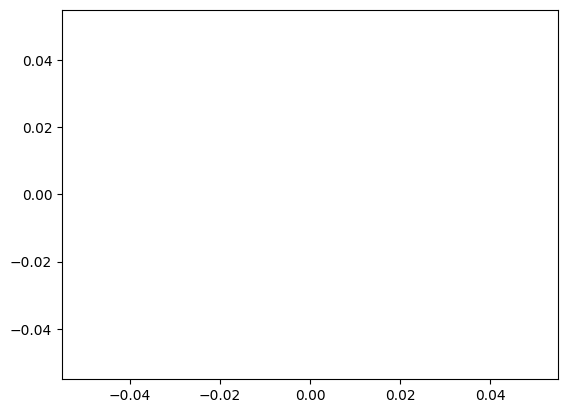

In [18]:
import seaborn as sns

import matplotlib.pyplot as plt

sns.histplot(video_lengths_df["duration_seconds"].dropna(), bins=30, kde=True)
plt.show()